# 15 Transit Accessibility Index v2

## Purpose

This notebook creates a stronger Transit Accessibility Index for Harris County census tracts.

The first version only considered population density and nearby stop counts. This v2 index adds more transit context by combining:

- Nearby METRO stops
- Route frequency
- Access to high-productivity routes
- Distance to METRORail stations

## Research Question

Which high-density census tracts appear to have weaker transit access when stop access, service frequency, route productivity, and rail proximity are considered together?

## Inputs

- `data/processed/harris_tracts_density.geojson`
- `data/raw/metro_gtfs/merged/stops.txt`
- `data/raw/metro_gtfs/merged/routes.txt`
- `data/raw/metro_gtfs/merged/trips.txt`
- `data/raw/metro_gtfs/merged/stop_times.txt`
- `data/processed/route_frequency.csv`
- `data/processed/route_efficiency_summary.csv`

## Outputs

- `data/processed/transit_accessibility_index_v2.geojson`

## Index Components

Each census tract receives four normalized access scores:

| Component | Weight |
|---|---:|
| Stop Count Score | 25% |
| Route Frequency Score | 25% |
| High Productivity Route Score | 25% |
| Rail Access Score | 25% |

The final accessibility score is the weighted average of those four components.

A separate underserved score highlights dense tracts with lower overall accessibility.


## 1. Import Libraries

GeoPandas handles spatial analysis, Pandas handles tabular GTFS and route-performance data, and Matplotlib creates static maps.

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path

## 2. Load Census Tract Density Data

This tract file was created earlier by combining Harris County tract geometries with ACS population data.

The key field for this notebook is `pop_density`, which represents population density by census tract.

In [2]:
tracts = gpd.read_file(
    "../data/processed/harris_tracts_density.geojson"
)

print(tracts.shape)
tracts.head()

(1115, 23)


,STATEFP,COUNTYFP,TRACTCE,GEOID,GEOIDFQ,NAME_x,NAMELSAD,MTFCC,FUNCSTAT,ALAND,...,NAME_y,B01003_001E,B19013_001E,state,county,tract,population,land_sq_miles,pop_density,geometry
0,48,201,323701,48201323701,1400000US48201323701,3237.01,Census Tract 3237.01,G5020,S,2311208,...,Census Tract 3237.01; Harris County; Texas,4504,54020,48,201,323701,4504,0.892362,5047.276769,"POLYGON ((-95.18667 29.66507, -95.18633 29.665..."
1,48,201,241103,48201241103,1400000US48201241103,2411.03,Census Tract 2411.03,G5020,S,2782048,...,Census Tract 2411.03; Harris County; Texas,4606,88482,48,201,241103,4606,1.074155,4288.022793,"POLYGON ((-95.3915 30.05522, -95.39134 30.0553..."
2,48,201,450801,48201450801,1400000US48201450801,4508.01,Census Tract 4508.01,G5020,S,903291,...,Census Tract 4508.01; Harris County; Texas,1914,80234,48,201,450801,1914,0.348763,5487.973690,"POLYGON ((-95.57635 29.76008, -95.57634 29.760..."
3,48,201,454302,48201454302,1400000US48201454302,4543.02,Census Tract 4543.02,G5020,S,2750427,...,Census Tract 4543.02; Harris County; Texas,5808,71463,48,201,454302,5808,1.061946,5469.205670,"POLYGON ((-95.68708 29.71008, -95.68669 29.710..."
4,48,201,451902,48201451902,1400000US48201451902,4519.02,Census Tract 4519.02,G5020,S,2057671,...,Census Tract 4519.02; Harris County; Texas,2593,130469,48,201,451902,2593,0.794471,3263.806104,"POLYGON ((-95.60573 29.72978, -95.60278 29.729..."


## 3. Load GTFS Transit Data

The GTFS feed provides stop locations, route metadata, trip records, and stop-time records.

These files allow the notebook to estimate which routes and services are reachable near each census tract.

In [3]:
stops = pd.read_csv(
    "../data/raw/metro_gtfs/merged/stops.txt"
)

routes = pd.read_csv(
    "../data/raw/metro_gtfs/merged/routes.txt"
)

trips = pd.read_csv(
    "../data/raw/metro_gtfs/merged/trips.txt",
    usecols=["route_id", "trip_id"]
)

stop_times = pd.read_csv(
    "../data/raw/metro_gtfs/merged/stop_times.txt",
    usecols=["trip_id", "stop_id"]
)

print("stops:", stops.shape)
print("routes:", routes.shape)
print("trips:", trips.shape)
print("stop_times:", stop_times.shape)

stops: (8896, 12)
routes: (116, 9)
trips: (47160, 2)
stop_times: (2927056, 2)


## 4. Load Route Performance and Frequency Data

Route productivity comes from Notebook 13.

Route frequency comes from earlier GTFS processing and is used here as a proxy for how much scheduled service is available near each tract.

In [4]:
route_efficiency = pd.read_csv(
    "../data/processed/route_efficiency_summary.csv"
)

route_frequency = pd.read_csv(
    "../data/processed/route_frequency.csv"
)

print("route_efficiency:", route_efficiency.shape)
print("route_frequency:", route_frequency.shape)

route_efficiency.head()

route_efficiency: (90, 8)
route_frequency: (116, 10)


,route_id,route_name,avg_weekday_boardings,avg_boardings_per_revenue_hour,avg_boardings_per_revenue_mile,avg_saturday_boardings,avg_sunday_boardings,months_observed
0,2,Bellaire,7185.166667,29.880000,2.730000,5446.333333,4390.583333,12
1,3,Langley / Little York,2156.250000,16.979167,1.304167,1740.250000,1465.333333,12
2,4,Beechnut,8093.416667,25.177500,2.008333,5038.583333,4109.750000,12
3,5,Southmore,1195.833333,17.502500,1.488333,697.416667,537.583333,12
4,6,Jensen / Greens,3836.166667,20.087500,1.374167,2808.833333,2283.250000,12


## 5. Standardize Route ID Types

GTFS route IDs and processed route-performance IDs can sometimes load as different data types.

This step standardizes route IDs as strings so the joins work correctly.

In [5]:
for df in [routes, trips, route_efficiency, route_frequency]:
    df["route_id"] = df["route_id"].astype(str)

stop_times["stop_id"] = stop_times["stop_id"].astype(str)
stops["stop_id"] = stops["stop_id"].astype(str)

## 6. Convert Stops to a GeoDataFrame

The GTFS stop latitude and longitude fields are converted into point geometries.

This makes it possible to spatially join stops to census tract buffers.

In [6]:
stops_gdf = gpd.GeoDataFrame(
    stops,
    geometry=gpd.points_from_xy(
        stops["stop_lon"],
        stops["stop_lat"]
    ),
    crs="EPSG:4326"
)

stops_gdf.head()

,stop_lat,wheelchair_boarding,stop_code,stop_lon,stop_timezone,stop_url,parent_station,stop_desc,stop_name,location_type,stop_id,zone_id,geometry
0,29.710980,0,2230,-95.361930,NaN,NaN,NaN,TIERWESTER ST & N MAC GREGOR WAY,Tierwester St @ N Mac Gregor Way,0,2230_merged_11814548,NaN,POINT (-95.36193 29.71098)
1,29.677330,0,6972,-95.490065,NaN,NaN,NaN,N BRAESWOOD BLVD & PONTIAC DR,Braeswood Blvd @ Pontiac Dr,0,6972,NaN,POINT (-95.49006 29.67733)
2,29.810142,0,11546,-95.471807,NaN,NaN,NaN,HEMPSTEAD RD & FAIRWAY PARK DR,Hempstead Rd @ Fairway Park Dr Mb,0,11546,NaN,POINT (-95.47181 29.81014)
3,29.809963,0,11547,-95.471925,NaN,NaN,NaN,HEMPSTEAD RD & ANTOINE DR,Hempstead Rd @ Antoine Dr,0,11547,NaN,POINT (-95.47192 29.80996)
4,29.802517,0,11545,-95.509738,NaN,NaN,NaN,LONG POINT RD & SPRING BRANCH RD,Long Point Rd @ Spring Branch Rd,0,11545,NaN,POINT (-95.50974 29.80252)


## 7. Project Spatial Layers

Distance calculations should not be performed directly in latitude and longitude.

This notebook projects tracts and stops to EPSG:3857 so that distances and buffers are measured in meters.

In [7]:
tracts_projected = tracts.to_crs("EPSG:3857")
stops_projected = stops_gdf.to_crs("EPSG:3857")

print(tracts_projected.crs)
print(stops_projected.crs)

EPSG:3857
EPSG:3857


## 8. Create Tract Centroids and Walking Buffers

Each census tract is represented by its centroid for this index.

An 800-meter buffer is created around each centroid as a rough approximation of a 10-minute walking distance.

In [8]:
tracts_projected["centroid"] = tracts_projected.geometry.centroid

tract_centroids = tracts_projected.copy()
tract_centroids = tract_centroids.set_geometry("centroid")

tract_buffers = tract_centroids.copy()
tract_buffers["geometry"] = tract_buffers.geometry.buffer(800)

tract_buffers.head()

,STATEFP,COUNTYFP,TRACTCE,GEOID,GEOIDFQ,NAME_x,NAMELSAD,MTFCC,FUNCSTAT,ALAND,...,B01003_001E,B19013_001E,state,county,tract,population,land_sq_miles,pop_density,geometry,centroid
0,48,201,323701,48201323701,1400000US48201323701,3237.01,Census Tract 3237.01,G5020,S,2311208,...,4504,54020,48,201,323701,4504,0.892362,5047.276769,"POLYGON ((-10594452.452 3459631.623, -10594456...",POINT (-10595252.452 3459631.623)
1,48,201,241103,48201241103,1400000US48201241103,2411.03,Census Tract 2411.03,G5020,S,2782048,...,4606,88482,48,201,241103,4606,1.074155,4288.022793,"POLYGON ((-10616793.689 3509683.931, -10616797...",POINT (-10617593.689 3509683.931)
2,48,201,450801,48201450801,1400000US48201450801,4508.01,Census Tract 4508.01,G5020,S,903291,...,1914,80234,48,201,450801,1914,0.348763,5487.973690,"POLYGON ((-10637861.493 3472760.738, -10637865...",POINT (-10638661.493 3472760.738)
3,48,201,454302,48201454302,1400000US48201454302,4543.02,Census Tract 4543.02,G5020,S,2750427,...,5808,71463,48,201,454302,5808,1.061946,5469.205670,"POLYGON ((-10649152.39 3466958.119, -10649156....",POINT (-10649952.39 3466958.119)
4,48,201,451902,48201451902,1400000US48201451902,4519.02,Census Tract 4519.02,G5020,S,2057671,...,2593,130469,48,201,451902,2593,0.794471,3263.806104,"POLYGON ((-10641199.105 3467931.575, -10641202...",POINT (-10641999.105 3467931.575)


## 9. Count Nearby Stops

This step counts how many METRO stops fall within 800 meters of each tract centroid.

The spatial join uses tract buffers as the left layer and stops as the right layer so that stop counts are correctly assigned to each tract.

In [9]:
stops_near_tracts = gpd.sjoin(
    tract_buffers,
    stops_projected,
    how="left",
    predicate="contains"
)

stop_counts = (
    stops_near_tracts
    .dropna(subset=["stop_id"])
    .groupby("GEOID")
    .size()
    .reset_index(name="stops_within_800m")
)

print(stop_counts.shape)
stop_counts["stops_within_800m"].describe()

(0, 2)


count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: stops_within_800m, dtype: float64

## 10. Build Stop-to-Route Service Table

To estimate transit service near each tract, stops need to be linked to the routes that serve them.

This section uses `stop_times.txt` and `trips.txt` to determine which route IDs serve each stop.

In [10]:
stop_routes = (
    stop_times
    .merge(
        trips,
        on="trip_id",
        how="left"
    )
    .dropna(subset=["route_id"])
    [["stop_id", "route_id"]]
    .drop_duplicates()
)

print(stop_routes.shape)
stop_routes.head()

(11365, 2)


,stop_id,route_id
0,13217,500
1,13218,500
2,13205,500
3,244,500
4,654,500


## 11. Create Route Frequency Lookup

The route frequency file contains scheduled trips by route.

This step keeps only the fields needed for the accessibility index.

In [11]:
frequency_lookup = route_frequency[
    [
        "route_id",
        "scheduled_trips"
    ]
].copy()

frequency_lookup["scheduled_trips"] = pd.to_numeric(
    frequency_lookup["scheduled_trips"],
    errors="coerce"
).fillna(0)

frequency_lookup.head()

,route_id,scheduled_trips
0,98,226.0
1,99,414.0
2,212,102.0
3,23,204.0
4,217,184.0


## 12. Calculate Route Frequency Access by Tract

This step identifies the unique routes reachable from stops within each tract buffer.

For each tract, it calculates:

- Number of nearby unique routes
- Sum of scheduled trips across those nearby routes

This becomes the route frequency component of the index.

In [12]:
nearby_stop_routes = (
    stops_near_tracts
    .dropna(subset=["stop_id"])
    [["GEOID", "stop_id"]]
    .drop_duplicates()
    .merge(
        stop_routes,
        on="stop_id",
        how="left"
    )
    .dropna(subset=["route_id"])
    .drop_duplicates(subset=["GEOID", "route_id"])
)

nearby_route_frequency = nearby_stop_routes.merge(
    frequency_lookup,
    on="route_id",
    how="left"
)

route_frequency_by_tract = (
    nearby_route_frequency
    .groupby("GEOID")
    .agg(
        nearby_routes=("route_id", "nunique"),
        nearby_scheduled_trips=("scheduled_trips", "sum")
    )
    .reset_index()
)

print(route_frequency_by_tract.shape)
route_frequency_by_tract.head()

(0, 3)


,GEOID,nearby_routes,nearby_scheduled_trips


## 13. Identify High-Productivity Routes

High-productivity routes are defined using the route productivity dataset from Notebook 13.

This version classifies a route as high-productivity if it falls in the top 25% of routes by `productivity_score`.

If the productivity score is not already present, it is calculated as:

`avg_boardings_per_revenue_hour × avg_boardings_per_revenue_mile`


In [13]:
route_efficiency = route_efficiency.copy()

if "productivity_score" not in route_efficiency.columns:
    route_efficiency["productivity_score"] = (
        route_efficiency["avg_boardings_per_revenue_hour"]
        *
        route_efficiency["avg_boardings_per_revenue_mile"]
    )

productivity_threshold = route_efficiency["productivity_score"].quantile(0.75)

high_productivity_routes = route_efficiency[
    route_efficiency["productivity_score"] >= productivity_threshold
][["route_id", "route_name", "productivity_score"]].copy()

high_productivity_routes["route_id"] = high_productivity_routes["route_id"].astype(str)

print("High productivity threshold:", productivity_threshold)
print(high_productivity_routes.shape)

high_productivity_routes.sort_values(
    "productivity_score",
    ascending=False
).head(10)

High productivity threshold: 36.218572395833334
(23, 3)


,route_id,route_name,productivity_score
40,63,Fondren,115.199822
48,73,Bellfort,102.275026
6,8,West Bellfort,93.982717
28,46,Gessner,92.662396
0,2,Bellaire,81.572400
42,65,Bissonnet,68.643042
55,82,Westheimer,63.803819
39,60,Cambridge,63.133585
35,54,Scott,62.204206
29,47,Hillcroft,57.458363


## 14. Calculate High-Productivity Route Access by Tract

This step counts how many high-productivity routes are reachable within each tract's 800-meter buffer.

This helps identify whether a tract has access not just to stops, but to strong-performing transit corridors.

In [14]:
nearby_high_productivity = nearby_stop_routes.merge(
    high_productivity_routes[["route_id", "productivity_score"]],
    on="route_id",
    how="inner"
)

high_productivity_by_tract = (
    nearby_high_productivity
    .groupby("GEOID")
    .agg(
        high_productivity_routes_nearby=("route_id", "nunique"),
        high_productivity_score_sum=("productivity_score", "sum")
    )
    .reset_index()
)

print(high_productivity_by_tract.shape)
high_productivity_by_tract.head()

(0, 3)


,GEOID,high_productivity_routes_nearby,high_productivity_score_sum


## 15. Calculate Distance to Nearest Rail Station

GTFS route type `0` represents light rail.

This section identifies stops served by rail routes and calculates the distance from each tract centroid to the nearest rail station.

The closer a tract is to rail, the higher its rail access score will be.

In [15]:
rail_route_ids = routes[
    routes["route_type"] == 0
]["route_id"].astype(str).unique()

rail_trip_ids = trips[
    trips["route_id"].isin(rail_route_ids)
]["trip_id"].unique()

rail_stop_ids = stop_times[
    stop_times["trip_id"].isin(rail_trip_ids)
]["stop_id"].astype(str).unique()

rail_stops_projected = stops_projected[
    stops_projected["stop_id"].astype(str).isin(rail_stop_ids)
].copy()

print("Rail routes:", rail_route_ids)
print("Rail stops:", rail_stops_projected.shape)

if len(rail_stops_projected) > 0:
    rail_union = rail_stops_projected.geometry.union_all()

    tract_centroids["distance_to_rail_m"] = (
        tract_centroids.geometry.distance(rail_union)
    )
else:
    tract_centroids["distance_to_rail_m"] = None

tract_centroids[["GEOID", "distance_to_rail_m"]].head()

Rail routes: ['700' '900' '800']
Rail stops: (85, 13)


,GEOID,distance_to_rail_m
0,48201323701,17062.220379
1,48201241103,27654.425929
2,48201450801,19753.814449
3,48201454302,29626.663231
4,48201451902,21835.597551


## 16. Merge All Accessibility Components

This combines the four index components into one census tract dataset:

- Stop count
- Route frequency
- High-productivity route access
- Rail distance

Missing values are filled with zero where appropriate.

In [16]:
access = tracts_projected.merge(
    stop_counts,
    on="GEOID",
    how="left"
)

access = access.merge(
    route_frequency_by_tract,
    on="GEOID",
    how="left"
)

access = access.merge(
    high_productivity_by_tract,
    on="GEOID",
    how="left"
)

access = access.merge(
    tract_centroids[["GEOID", "distance_to_rail_m"]],
    on="GEOID",
    how="left"
)

access = gpd.GeoDataFrame(
    access,
    geometry="geometry",
    crs=tracts_projected.crs
)

fill_cols = [
    "stops_within_800m",
    "nearby_routes",
    "nearby_scheduled_trips",
    "high_productivity_routes_nearby",
    "high_productivity_score_sum"
]

for col in fill_cols:
    access[col] = access[col].fillna(0)

print(access.shape)

access[
    [
        "GEOID",
        "population",
        "pop_density",
        "stops_within_800m",
        "nearby_routes",
        "nearby_scheduled_trips",
        "high_productivity_routes_nearby",
        "distance_to_rail_m"
    ]
].head()

(1115, 30)


,GEOID,population,pop_density,stops_within_800m,nearby_routes,nearby_scheduled_trips,high_productivity_routes_nearby,distance_to_rail_m
0,48201323701,4504,5047.276769,0.0,0.0,0.0,0.0,17062.220379
1,48201241103,4606,4288.022793,0.0,0.0,0.0,0.0,27654.425929
2,48201450801,1914,5487.973690,0.0,0.0,0.0,0.0,19753.814449
3,48201454302,5808,5469.205670,0.0,0.0,0.0,0.0,29626.663231
4,48201451902,2593,3263.806104,0.0,0.0,0.0,0.0,21835.597551


## 17. Normalize Component Scores

Each accessibility component is normalized to a 0–1 range so the four measures can be combined.

For rail access, lower distance is better. Tracts within 5,000 meters of rail receive a higher rail access score, while farther tracts approach zero.

In [17]:
def normalize_max(series):
    max_value = series.max()

    if pd.isna(max_value) or max_value == 0:
        return series * 0

    return series / max_value


access["stop_count_score"] = normalize_max(
    access["stops_within_800m"]
)

access["route_frequency_score"] = normalize_max(
    access["nearby_scheduled_trips"]
)

access["high_productivity_route_score"] = normalize_max(
    access["high_productivity_routes_nearby"]
)

rail_distance_limit = 5000

access["rail_access_score"] = (
    1 - (access["distance_to_rail_m"] / rail_distance_limit)
).clip(lower=0, upper=1)

access[
    [
        "GEOID",
        "stop_count_score",
        "route_frequency_score",
        "high_productivity_route_score",
        "rail_access_score"
    ]
].head()

,GEOID,stop_count_score,route_frequency_score,high_productivity_route_score,rail_access_score
0,48201323701,0.0,0.0,0.0,0.0
1,48201241103,0.0,0.0,0.0,0.0
2,48201450801,0.0,0.0,0.0,0.0
3,48201454302,0.0,0.0,0.0,0.0
4,48201451902,0.0,0.0,0.0,0.0


## 18. Calculate Accessibility Score v2

The final accessibility score is an equal-weighted index:

- Stop Count Score: 25%
- Route Frequency Score: 25%
- High Productivity Route Score: 25%
- Rail Access Score: 25%

A higher score indicates stronger transit access.

In [18]:
access["accessibility_score_v2"] = (
    0.25 * access["stop_count_score"]
    + 0.25 * access["route_frequency_score"]
    + 0.25 * access["high_productivity_route_score"]
    + 0.25 * access["rail_access_score"]
)

access[
    [
        "GEOID",
        "pop_density",
        "accessibility_score_v2",
        "stop_count_score",
        "route_frequency_score",
        "high_productivity_route_score",
        "rail_access_score"
    ]
].sort_values(
    "accessibility_score_v2",
    ascending=False
).head(20)

,GEOID,pop_density,accessibility_score_v2,stop_count_score,route_frequency_score,high_productivity_route_score,rail_access_score
243,48201314401,7913.188085,0.241649,0.0,0.0,0.0,0.966597
945,48201310900,6727.222515,0.241294,0.0,0.0,0.0,0.965177
1009,48201210400,5586.051273,0.241162,0.0,0.0,0.0,0.964648
886,48201980700,3292.137508,0.240714,0.0,0.0,0.0,0.962858
477,48201100001,5526.559111,0.232590,0.0,0.0,0.0,0.930361
317,48201312000,4818.853171,0.231820,0.0,0.0,0.0,0.927282
194,48201410601,14850.567759,0.230947,0.0,0.0,0.0,0.923789
210,48201312502,7022.067730,0.226565,0.0,0.0,0.0,0.906258
835,48201210600,5942.890167,0.226190,0.0,0.0,0.0,0.904758
321,48201312200,3785.981953,0.226169,0.0,0.0,0.0,0.904675


## 19. Calculate Underserved Score v2

The underserved score identifies dense tracts with weaker transit accessibility.

It combines normalized population density with the inverse of the accessibility score:

`underserved_score_v2 = density_score × (1 - accessibility_score_v2)`

Higher values indicate areas that are dense but comparatively less accessible.

In [19]:
access["density_score"] = normalize_max(
    access["pop_density"]
)

access["underserved_score_v2"] = (
    access["density_score"]
    *
    (1 - access["accessibility_score_v2"])
)

access[
    [
        "GEOID",
        "population",
        "pop_density",
        "density_score",
        "accessibility_score_v2",
        "underserved_score_v2"
    ]
].sort_values(
    "underserved_score_v2",
    ascending=False
).head(20)

,GEOID,population,pop_density,density_score,accessibility_score_v2,underserved_score_v2
1105,48201421402,3896,62579.265568,1.000000,0.000000,1.000000
496,48201451003,4133,45250.341810,0.723088,0.000000,0.723088
174,48201421204,3472,38365.937888,0.613077,0.000000,0.613077
229,48201431205,3045,36318.945755,0.580367,0.000000,0.580367
738,48201433506,1816,36308.337961,0.580198,0.000000,0.580198
177,48201421301,3742,36303.257747,0.580116,0.000000,0.580116
178,48201421206,2204,35302.002439,0.564117,0.000000,0.564117
824,48201333204,2211,34909.798527,0.557849,0.000000,0.557849
931,48201240503,2863,34304.716333,0.548180,0.000000,0.548180
1046,48201421401,3571,32381.312222,0.517445,0.000000,0.517445


## 20. Map Accessibility Score v2

This map shows overall transit accessibility.

Darker or more intense areas have stronger access based on nearby stops, service frequency, high-productivity routes, and rail proximity.

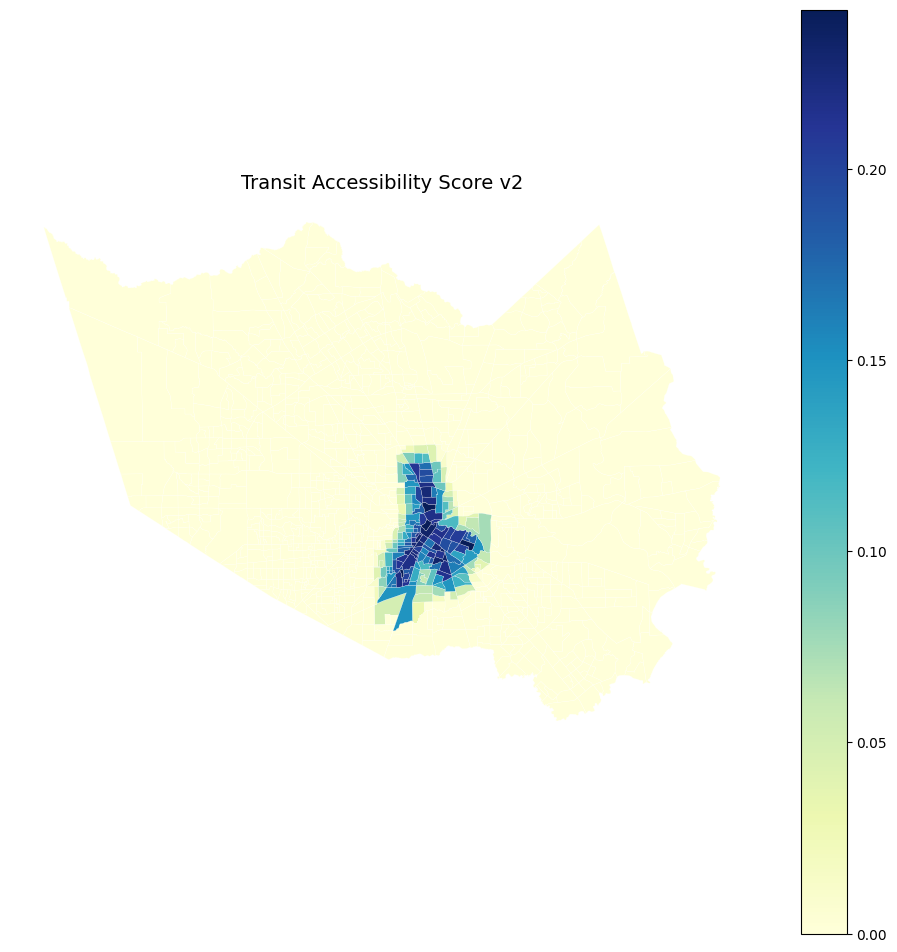

In [23]:
fig, ax = plt.subplots(figsize=(12, 12))

access.plot(
    column="accessibility_score_v2",
    cmap="YlGnBu",
    legend=True,
    ax=ax,
    linewidth=0.15,
    edgecolor="white"
)

ax.set_title(
    "Transit Accessibility Score v2",
    fontsize=14
)

ax.set_axis_off()

plt.show()

## 21. Map Underserved Score v2

This map highlights areas that combine higher population density with weaker overall transit accessibility.

The brightest areas are the strongest candidates for deeper service, equity, or investment analysis.

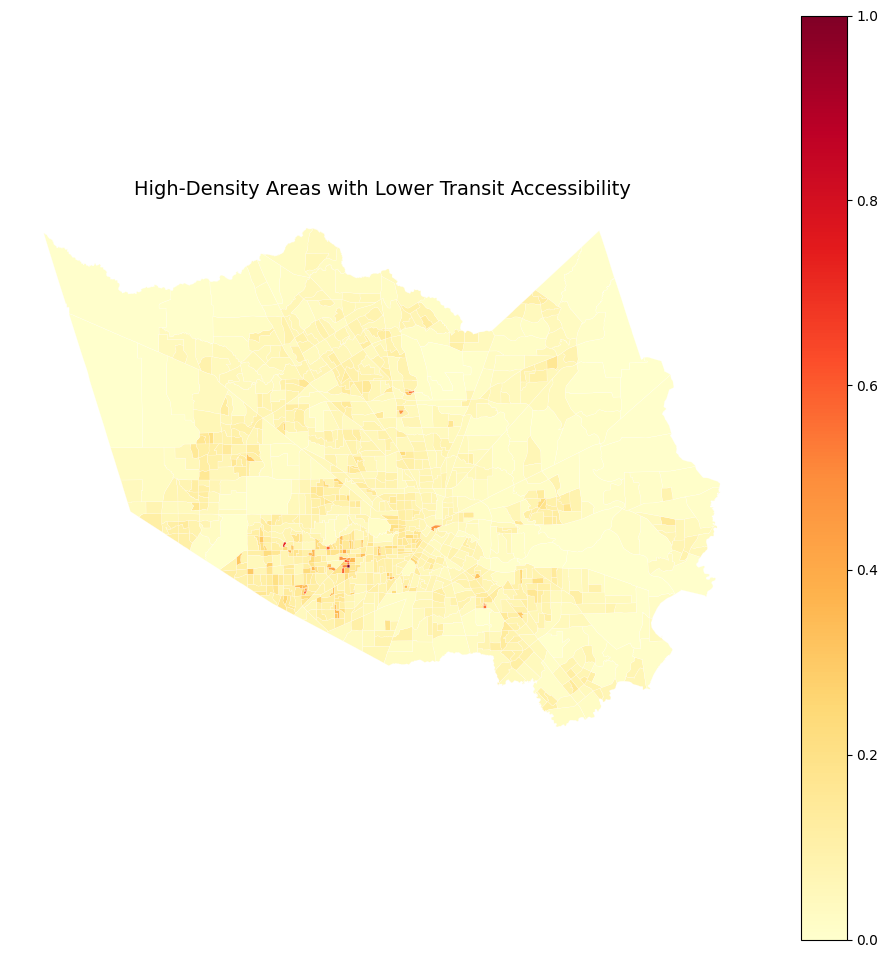

In [21]:
fig, ax = plt.subplots(figsize=(12, 12))

access.plot(
    column="underserved_score_v2",
    cmap="YlOrRd",
    legend=True,
    ax=ax,
    linewidth=0.15,
    edgecolor="white"
)

ax.set_title(
    "High-Density Areas with Lower Transit Accessibility",
    fontsize=14
)

ax.set_axis_off()

plt.show()

## 22. Save Accessibility Index v2

GeoJSON only supports one geometry column.

Because the notebook created centroid geometry earlier, the export step drops the extra centroid geometry before saving.

In [22]:
access_export = access.drop(
    columns=["centroid"],
    errors="ignore"
)

access_export = access_export.set_geometry("geometry")

access_export.to_crs("EPSG:4326").to_file(
    "../data/processed/transit_accessibility_index_v2.geojson",
    driver="GeoJSON"
)

print("saved")

saved


## Summary

This notebook creates a stronger Transit Accessibility Index for Harris County census tracts.

Unlike the first version, this v2 index considers multiple dimensions of transit access:

- Nearby stop count
- Scheduled route frequency
- Access to high-productivity routes
- Distance to METRORail stations

The final `accessibility_score_v2` measures overall access, while `underserved_score_v2` highlights high-density tracts with weaker transit accessibility.

## Limitations

This index is still a planning proxy. It does not yet include:

- Actual walking network distance
- Sidewalk quality
- Fare cost
- Transfers
- Travel time to jobs
- Vehicle ownership
- Income or race/ethnicity equity variables

However, it is a much stronger foundation for future transit investment and rail expansion analysis than a stop-count-only index.
